# Kiểm tra độ dài title + abstract của từng bài báo trong corpus

--- THỐNG KÊ 1000 BÀI BÁO ---
Ngắn nhất: 21 ký tự
Dài nhất : 4092 ký tự
Trung bình: 1116 ký tự


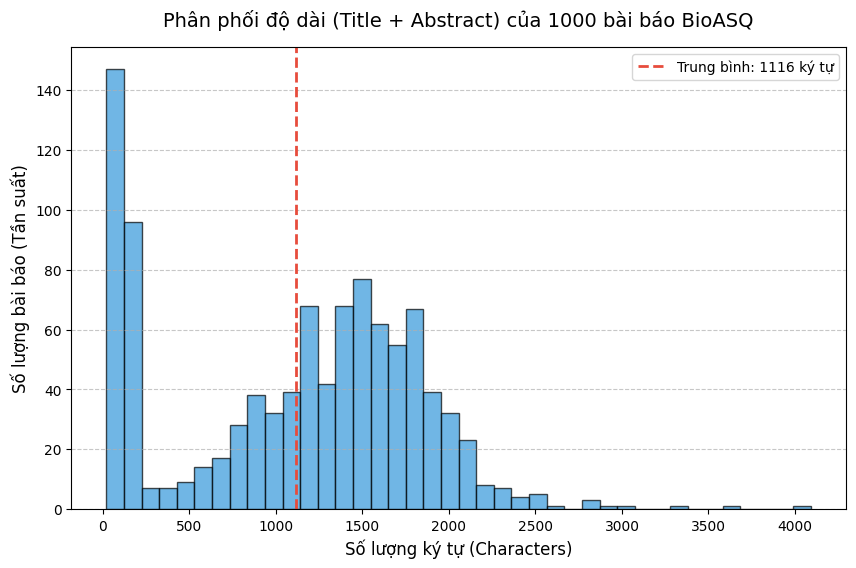

In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt


def analyze_corpus_length(file_path: str, num_samples: int = 1000):
    lengths = []

    # Đọc file JSONL từng dòng (tiết kiệm RAM)
    with open(file_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= num_samples:
                break

            try:
                doc = json.loads(line)
                title = doc.get("title", "")
                # BioASQ có thể dùng "abstractText" hoặc "abstract"
                abstract = doc.get("abstractText") or doc.get("abstract", "")

                # Tính tổng số ký tự
                total_length = len(title) + len(abstract)
                lengths.append(total_length)
            except json.JSONDecodeError:
                continue

    if not lengths:
        print("Không tìm thấy dữ liệu hợp lệ!")
        return

    # Vẽ biểu đồ Histogram
    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=40, color="#3498db", edgecolor="black", alpha=0.7)

    # Thống kê cơ bản
    mean_len = sum(lengths) / len(lengths)
    max_len = max(lengths)
    min_len = min(lengths)

    # Vẽ đường trung bình
    plt.axvline(
        mean_len,
        color="#e74c3c",
        linestyle="dashed",
        linewidth=2,
        label=f"Trung bình: {mean_len:.0f} ký tự",
    )

    plt.title(
        f"Phân phối độ dài (Title + Abstract) của {len(lengths)} bài báo BioASQ",
        fontsize=14,
        pad=15,
    )
    plt.xlabel("Số lượng ký tự (Characters)", fontsize=12)
    plt.ylabel("Số lượng bài báo (Tần suất)", fontsize=12)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # In thông số ra console
    print(f"--- THỐNG KÊ {len(lengths)} BÀI BÁO ---")
    print(f"Ngắn nhất: {min_len} ký tự")
    print(f"Dài nhất : {max_len} ký tự")
    print(f"Trung bình: {mean_len:.0f} ký tự")

    # Lưu ảnh và hiển thị
    plt.savefig("abstract_length_histogram.png", dpi=300, bbox_inches="tight")
    plt.show()

# Tự tìm file corpus theo các vị trí phổ biến trong repo
candidate_paths = [
    Path("data/corpus/corpus.jsonl"),
    Path("../data/corpus/corpus.jsonl"),
    Path("data/raw/corpus.jsonl"),
    Path("../data/raw/corpus.jsonl"),
]

corpus_path = next((p for p in candidate_paths if p.exists()), None)
if corpus_path is None:
    raise FileNotFoundError(
        "Không tìm thấy corpus.jsonl. Hãy kiểm tra lại trong data/corpus/ hoặc data/raw/."
    )

analyze_corpus_length(str(corpus_path), num_samples=1000)